In [1]:
#imported essential libraries
import os
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
#reading the image its size and mode
image = Image.open("FullIJCNN2013/00004.ppm")

print(image.size)
print(image.mode)



(1360, 800)
RGB


In [ ]:
#displaying the first five image
for i in range(6):
    image = Image.open(f'FullIJCNN2013/{i:05d}.ppm')

    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.title(f"Image {i:05d}")
    plt.axis("off")
    plt.show()

In [4]:
#reading the ground truth file which contains the bounding boxes(annotations) of each traffic sign in the data
gt_path = 'FullIJCNN2013/gt.txt'

with open(gt_path) as f:
    lines = f.readlines()
    
print(lines[:10])

['00000.ppm;774;411;815;446;11\n', '00001.ppm;983;388;1024;432;40\n', '00001.ppm;386;494;442;552;38\n', '00001.ppm;973;335;1031;390;13\n', '00002.ppm;892;476;1006;592;39\n', '00003.ppm;742;443;765;466;4\n', '00003.ppm;742;466;764;489;9\n', '00003.ppm;737;412;769;443;21\n', '00004.ppm;898;342;967;409;21\n', '00004.ppm;906;407;955;459;2\n']


In [5]:
#storing the annotations of traffic signs for first 5  image
res = {}
for i in range(5):
    image_name = f'{i:05d}.ppm'
    annotations = []
    for line in lines:
        parts = line.strip().split(';')
        if parts[0] == image_name:
            annotations.append(parts[1:])
    res[image_name] = annotations
print(res)

{'00000.ppm': [['774', '411', '815', '446', '11']], '00001.ppm': [['983', '388', '1024', '432', '40'], ['386', '494', '442', '552', '38'], ['973', '335', '1031', '390', '13']], '00002.ppm': [['892', '476', '1006', '592', '39']], '00003.ppm': [['742', '443', '765', '466', '4'], ['742', '466', '764', '489', '9'], ['737', '412', '769', '443', '21']], '00004.ppm': [['898', '342', '967', '409', '21'], ['906', '407', '955', '459', '2']]}


In [ ]:
#displaying the bounding boxes for the images checking if the annotations are correct or not 
import matplotlib.patches as patches

   # change this to your path

for image_name, annotations in res.items():

    # Load image
    image_path = f"FullIJCNN2013/{image_name}"
    image = Image.open(image_path)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 7))

    # Display image
    ax.imshow(image)

    # Draw every bounding box in this image
    for annotation in annotations:

        left = int(annotation[0])
        top = int(annotation[1])
        right = int(annotation[2])
        bottom = int(annotation[3])
        class_id = int(annotation[4])

        width = right - left
        height = bottom - top

        # Bounding box
        rectangle = patches.Rectangle(
            (left, top),
            width,
            height,
            linewidth=0.7,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rectangle)

        # Class name
        ax.text(
            left,
            max(0, top - 5),
            [class_id],
            fontsize=12,
            color="blue",
            fontweight="bold"
        )

    ax.set_title(image_name)
    ax.axis("off")

    plt.show()

In [ ]:
#identifying the no of traffic signs contained by each image 
image_annotations = {}

for line in lines:
    parts = line.strip().split(";")

    image_name = parts[0]

    if image_name not in image_annotations:
        image_annotations[image_name] = []

    image_annotations[image_name].append(parts[1:])

for image, annotations in image_annotations.items():
        print(image, annotations)

print(len(image_annotations.keys()))

00000.ppm [['774', '411', '815', '446', '11']]
00001.ppm [['983', '388', '1024', '432', '40'], ['386', '494', '442', '552', '38'], ['973', '335', '1031', '390', '13']]
00002.ppm [['892', '476', '1006', '592', '39']]
00003.ppm [['742', '443', '765', '466', '4'], ['742', '466', '764', '489', '9'], ['737', '412', '769', '443', '21']]
00004.ppm [['898', '342', '967', '409', '21'], ['906', '407', '955', '459', '2']]
00005.ppm [['1172', '164', '1284', '278', '9']]
00006.ppm [['926', '350', '989', '414', '2']]
00007.ppm [['825', '406', '864', '445', '9']]
00008.ppm [['785', '460', '811', '486', '2'], ['779', '424', '816', '461', '12']]
00009.ppm [['925', '466', '949', '490', '4']]
00010.ppm [['1193', '358', '1269', '436', '12']]
00011.ppm [['720', '338', '770', '398', '1'], ['710', '265', '780', '342', '21']]
00012.ppm [['979', '364', '1034', '418', '1']]
00013.ppm [['1043', '281', '1120', '356', '2']]
00014.ppm [['712', '492', '732', '511', '21']]
00015.ppm [['770', '426', '808', '462', '25'

In [8]:
#identifying the image the with max no traffic signs
max_signs = max(len(annotations) for annotations in image_annotations.values())

print("Maximum number of signs:", max_signs)

for image, annotations in image_annotations.items():
    if len(annotations) == max_signs:
        print(image)

Maximum number of signs: 6
00073.ppm


In [ ]:
#analyzing How many times each ClassID appears in gt.txt across all the traffic-sign annotations.
from collections import Counter

class_count = Counter()

for image, annotations in image_annotations.items():
    for annotation in annotations:
        class_id = int(annotation[-1])
        class_count[class_id] += 1
print(class_count)

In [ ]:
#sorting the dictionary according to classes id and classifying the counts of the classes according 
# to there no. of appearances 
res1 = []
res2 = []
for class_id, count in sorted(class_count.items()):
    if count < 10:
        print(f'class {class_id}: {count}')
        res1.append(count)
    else:
        res2.append(count)

print(len(res1))
print(len(res2))
                

class 0: 4
class 16: 8
class 19: 2
class 20: 9
class 21: 5
class 24: 5
class 27: 3
class 29: 5
class 31: 2
class 32: 8
class 36: 9
class 37: 2
class 39: 6
class 41: 7
14
29


In [ ]:
#calculating the bounding boxes size 

box_size = []
for image, annotations in image_annotations.items():
    for annotation in annotations:
        left = int(annotation[0])
        top = int(annotation[1])
        right = int(annotation[2])
        bottom = int(annotation[3])

        width = right - left
        height = bottom - top

        box_size.append((image, width, height))


box_size

In [12]:
#smallest bounding box size
smallest_box = min(                       
    box_size,
    key=lambda x: x[1] * x[2]
)

print("Smallest bounding box:")
print(smallest_box)


#largest bounding box size
largest_box = max(                          
    box_size,
    key=lambda x: x[1] * x[2]
)

print("Largest bounding box:")
print(largest_box)


#average bounding box size
avg_width = sum(width for image, width, height in box_size) / len(box_size)

avg_height = sum(height for image, width, height in box_size) / len(box_size)

print("Average width:", avg_width)
print("Average height:", avg_height)

Smallest bounding box:
('00536.ppm', 16, 16)
Largest bounding box:
('00755.ppm', 124, 124)
Average width: 43.59934047815334
Average height: 42.86232481450948


In [13]:
#categorizing the bounding boxes into small medium and large 
small = 0
medium = 0
large = 0

for image, width, height in box_size:

    area = width * height

    if area < 1000:
        small += 1

    elif 1000< area < 5000:
        medium += 1

    else:
        large += 1

print("count of bounding boxes with Small area:", small)
print("count of bounding boxes with Medium area:", medium)
print("count of bounding boxes with Large area:", large)

count of bounding boxes with Small area: 424
count of bounding boxes with Medium area: 658
count of bounding boxes with Large area: 131


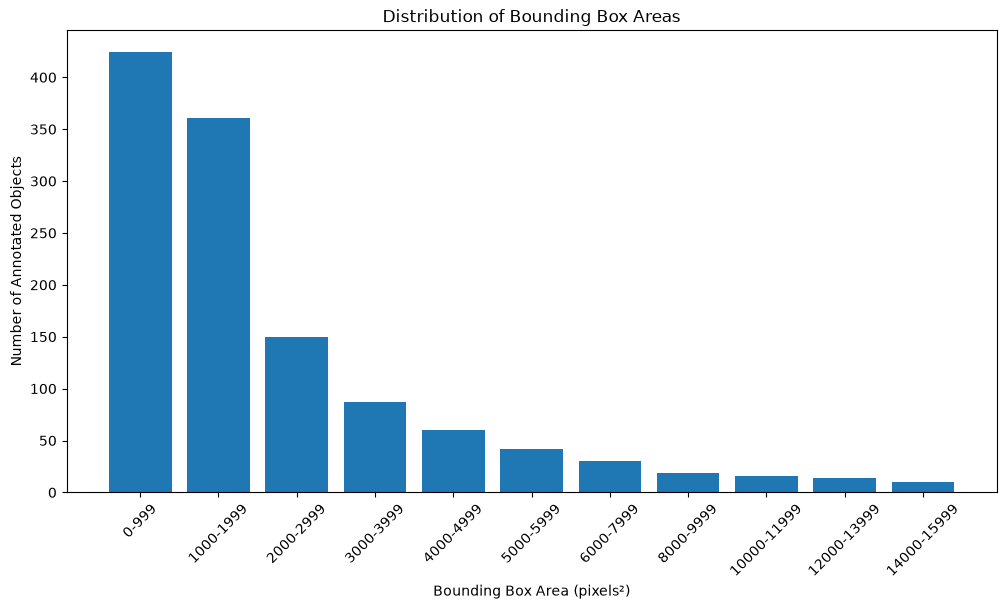

In [14]:
areas = [width * height for image, width, height in box_size]

bins = [0, 1000, 2000, 3000, 4000, 5000, 6000, 8000, 10000, 12000, 14000, 16000]

counts = []

for i in range(len(bins) - 1):
    count = sum(
        bins[i] <= area < bins[i + 1]
        for area in areas
    )
    counts.append(count)

labels = [
    f"{bins[i]}-{bins[i+1]-1}"
    for i in range(len(bins) - 1)
]

plt.figure(figsize=(12, 6))

plt.bar(labels, counts)

plt.xlabel("Bounding Box Area (pixels²)")
plt.ylabel("Number of Annotated Objects")
plt.title("Distribution of Bounding Box Areas")

plt.xticks(rotation=45)

plt.show()

In [14]:
print(image_annotations['00755.ppm'])

for i in box_size:
    if i[0] == '00755.ppm':
        print(i)

[['1084', '294', '1208', '418', '12'], ['852', '518', '883', '549', '1'], ['563', '595', '593', '625', '38']]
('00755.ppm', 124, 124)
('00755.ppm', 31, 31)
('00755.ppm', 30, 30)


In [ ]:
#displaying the traffic signs to observe the size of the bounding box for the traffic signs
image_path = 'FullIJCNN2013/00755.ppm'

image = Image.open(image_path)

fig, ax = plt.subplots(figsize=(12, 8))

ax.imshow(image)

for annotation in image_annotations['00755.ppm']:

    left = int(annotation[0])
    top = int(annotation[1])
    right = int(annotation[2])
    bottom = int(annotation[3])
    class_id = int(annotation[4])

    width = right - left
    height = bottom - top

    rectangle = patches.Rectangle(
        (left, top),
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rectangle)

    ax.text(
        left,
        top - 5,
        f"{class_id}",
        color="red",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(image_name)
ax.axis("off")

plt.show()

In [15]:
#splitting the data into train test 
from sklearn.model_selection import train_test_split

image_names = [file for file in os.listdir('FullIJCNN2013') if file.endswith(".ppm") ]
print(len(image_names))

train_val_images, test_images = train_test_split(
    image_names,
    test_size=0.15,
    random_state=42
)

print("Train + Validation:", len(train_val_images))
print("Test:", len(test_images))

900
Train + Validation: 765
Test: 135


In [16]:
#splitting the data into train and validation using the train set
train_images, val_images = train_test_split(
    train_val_images,
    test_size=0.1765,
    random_state=42
)

print('train:', len(train_images))
print('validation:',len(val_images))
print('test:',len(test_images))

train: 629
validation: 136
test: 135


In [17]:
#identifying the images with no traffic signs
missing_annotations = [
    image
    for image in image_names
    if image not in image_annotations
]

print("Images without annotations:", len(missing_annotations))
print(missing_annotations)

Images without annotations: 159
['00108.ppm', '00139.ppm', '00145.ppm', '00213.ppm', '00235.ppm', '00308.ppm', '00321.ppm', '00324.ppm', '00325.ppm', '00326.ppm', '00327.ppm', '00328.ppm', '00329.ppm', '00331.ppm', '00332.ppm', '00335.ppm', '00336.ppm', '00342.ppm', '00345.ppm', '00354.ppm', '00361.ppm', '00364.ppm', '00365.ppm', '00381.ppm', '00389.ppm', '00394.ppm', '00399.ppm', '00407.ppm', '00409.ppm', '00424.ppm', '00429.ppm', '00437.ppm', '00442.ppm', '00454.ppm', '00462.ppm', '00464.ppm', '00469.ppm', '00489.ppm', '00495.ppm', '00506.ppm', '00510.ppm', '00511.ppm', '00522.ppm', '00525.ppm', '00526.ppm', '00529.ppm', '00532.ppm', '00533.ppm', '00534.ppm', '00535.ppm', '00537.ppm', '00538.ppm', '00539.ppm', '00540.ppm', '00541.ppm', '00543.ppm', '00546.ppm', '00547.ppm', '00549.ppm', '00550.ppm', '00553.ppm', '00555.ppm', '00558.ppm', '00559.ppm', '00561.ppm', '00562.ppm', '00563.ppm', '00568.ppm', '00569.ppm', '00572.ppm', '00573.ppm', '00574.ppm', '00576.ppm', '00577.ppm', '0057

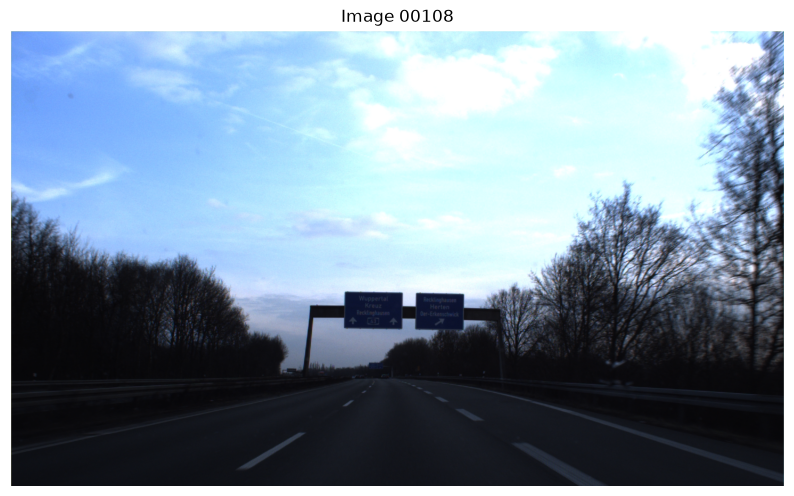

In [17]:
#verifying that image does not contain any traffic sign
image = Image.open('FullIJCNN2013/00354.ppm')

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.title(f"Image 00108")
plt.axis("off")
plt.show()

In [18]:
#creation of pytorch dataset class 
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms




class TrafficSignDataset(Dataset):

    def __init__(self, image_folder, image_names, image_annotations, transforms=None):

        self.image_folder = image_folder
        self.image_names = image_names
        self.image_annotations = image_annotations
        self.transforms = transforms

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, index):

        # Get image filename
        image_name = self.image_names[index]

        # Build image path
        image_path = os.path.join(
            self.image_folder,
            image_name
        )

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Get annotations
        annotations = self.image_annotations.get(
            image_name,
            []
        )

        boxes = []
        labels = []

        # Convert annotations
        for annotation in annotations:

            left = int(annotation[0])
            top = int(annotation[1])
            right = int(annotation[2])
            bottom = int(annotation[3])
            class_id = int(annotation[4])

            boxes.append([
                left,
                top,
                right,
                bottom
            ])

            # +1 because 0 is reserved for background
            labels.append(class_id + 1)

        # Convert to tensors
        boxes = torch.tensor(
            boxes,
            dtype=torch.float32

        ).reshape(-1, 4)

        labels = torch.tensor(
            labels,
            dtype=torch.int64
        )

        # Target dictionary
        target = {
            "boxes": boxes,
            "labels": labels
        }

        # Apply transforms if provided
        if self.transforms:
            image = self.transforms(image)

        return image, target

In [19]:
#instantiating the object of the dataset class and defining the transform that should be passed

transform = transforms.Compose([
    transforms.ToTensor()
])

image_folder = 'FullIJCNN2013/'
train_dataset = TrafficSignDataset(
    image_folder,
    train_images,
    image_annotations,
    transforms = transform
)

val_dataset = TrafficSignDataset(
    image_folder,
    val_images,
    image_annotations,
    transforms=transform
)

test_dataset = TrafficSignDataset(
    image_folder,
    test_images,
    image_annotations,
    transforms=transform
)

In [20]:
#verifiying any changes after the creating the dataset
# print("Train dataset:", len(train_dataset))
# print("Validation dataset:", len(val_dataset))
# print("Test dataset:", len(test_dataset))
images, target = train_dataset[1]
print(type(images))
print(images.shape)
images = images.permute(1, 2, 0)
print(images.shape)
print(target)


<class 'torch.Tensor'>
torch.Size([3, 800, 1360])
torch.Size([800, 1360, 3])
{'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64)}


In [21]:
#creation of train, val and test loaders to train the model
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn= collate_fn
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn= collate_fn
    )

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn= collate_fn
    )


In [ ]:
#checking the no of samples in batch and their labels and bounding boxes shape
images, targets = next(iter(train_loader))
print('number of images:', len(images))
print('number of targets:', len(targets))
for i, target in enumerate(targets):
    print(i, target["boxes"].shape, target["labels"].shape)

number of images: 4
number of targets: 4
0 torch.Size([2, 4]) torch.Size([2])
1 torch.Size([2, 4]) torch.Size([2])
2 torch.Size([1, 4]) torch.Size([1])
3 torch.Size([1, 4]) torch.Size([1])


In [ ]:
#using Faster CNN model with  resnet50 as backbone
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [ ]:
#model definition
train_classes = set()

#extraction of no of classes 
train_classes.update(target["labels"].tolist())
for _, target in train_dataset:                         

    num_classes = len(train_classes) + 1
    print(num_classes)

# assigning the default weights to the model
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT

model = fasterrcnn_resnet50_fpn(
    weights = weights
)


in_features = model.roi_heads.box_predictor.cls_score.in_features


#using the input features from roi head box predictor and assigning the no of classes for output
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

44


In [ ]:
#displaying the model architecture
print(model)

#calculating the no of paramters in the model  for training
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Trainable parameters:",
    trainable_params / 1e6,
    "M"
)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
#setting the model and images to the cpu for training
device = torch.device('cpu')
model = model.to(device)

images, targets = next(iter(train_loader))

images = [image.to(device) for image in images]

targets = [{key: value.to(device) for key, value in target.items()} for target in targets]

#verifying if the model works fine using one forward pass
model.train()
loss_dict = model(images, targets)

print(loss_dict)

{'loss_classifier': tensor(4.1315, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0230, grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0680, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0014, grad_fn=<DivBackward0>)}


In [ ]:
#setting all the parameters for training update
for param in model.parameters():
    param.requires_grad = True


In [ ]:
#defining optimizer in which only decided trainable paramters will get update
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr = 0.005,
    momentum = 0.9,
    weight_decay=0.0005
)
